In [8]:
import pyodbc
import pandas as pd
import warnings
import os
from dotenv import load_dotenv

load_dotenv()
server_name = os.getenv("server_name")
db_name = os.getenv("db_name")
username = os.getenv("username")
password = os.getenv("password")


conn_str = (
    f'DRIVER={{ODBC Driver 18 for SQL Server}};'
    f'SERVER={server_name};'
    f'DATABASE={db_name};'
    f'UID={username};'
    f'PWD={password};'
    f'Encrypt=yes;'
    f'TrustServerCertificate=yes;'
)

try:
    conn = pyodbc.connect(conn_str)
    query = """
    SELECT 
        s.order_id, s.order_date, s.quantity, s.sales, s.profit,
        c.customer_id, c.gender, c.annual_income, c.occupation,
        DATEDIFF(YEAR, c.birth_date, GETDATE()) AS age,
        p.product_code, p.product, p.category, p.subcategory,
        r.city, r.country, r.market
    FROM e_commerce.ecom_sales s
    JOIN e_commerce.customer c ON s.customer_id = c.customer_id
    JOIN e_commerce.product p ON s.product_code = p.product_code
    JOIN e_commerce.region r ON s.region_code = r.region_code;
    """
    
    df = pd.read_sql(query, conn)
    
    print("Done")
    print(f"Tổng số bản ghi tải về: {len(df)}")
    print(df.head())

except Exception as e:
    print(f"Lỗi truy vấn: {e}")

C:\Users\hieuh\AppData\Local\Temp\ipykernel_9384\3200310329.py:39: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, conn)


Done
Tổng số bản ghi tải về: 51287
                  order_id  order_date  quantity  sales  profit customer_id  \
0  MX-2012-CC1267082-41055  2020-05-26         3   96.0  -24.00  CC-1267082   
1  MX-2014-JL1523526-41815  2022-06-25         4  128.0   64.00  JL-1523526   
2  MX-2012-JG1511582-41196  2020-10-14         6  192.0   18.82  JG-1511582   
3  MX-2015-BF1127531-42348  2023-12-10        12  384.0  153.60  BF-1127531   
4  US-2014-BB1099098-41674  2022-02-04        15  480.0   48.00  BB-1099098   

  gender  annual_income    occupation  age product_code  \
0      F         130000    Management   59      P000001   
1      M          70000  Professional   33      P000001   
2      F         100000    Management   53      P000001   
3      M         130000    Management   36      P000001   
4      M          10000        Manual   35      P000001   

                                             product   category  \
0  Soap & Glory Endless Glove Moisturizing Hand C...  Body care   
1

### Pipeline Visualize cho Recommendation System
Cần trả lời 3 câu hỏi lớn:
- Sản phẩm: Những sản phẩm/danh mục nào phổ biến nhất? (Gợi ý cho khách mới).
- Khách hàng: Hành vi mua sắm của các nhóm tuổi/thu nhập khác nhau thế nào? (Gợi ý theo phân khúc).
- Mối quan hệ: Sự tương quan giữa các đặc tính khách hàng và sản phẩm họ mua.

C:\Users\hieuh\AppData\Local\Temp\ipykernel_9384\819601722.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_products.values, y=top_products.index, ax=axes[0, 0], palette='magma')


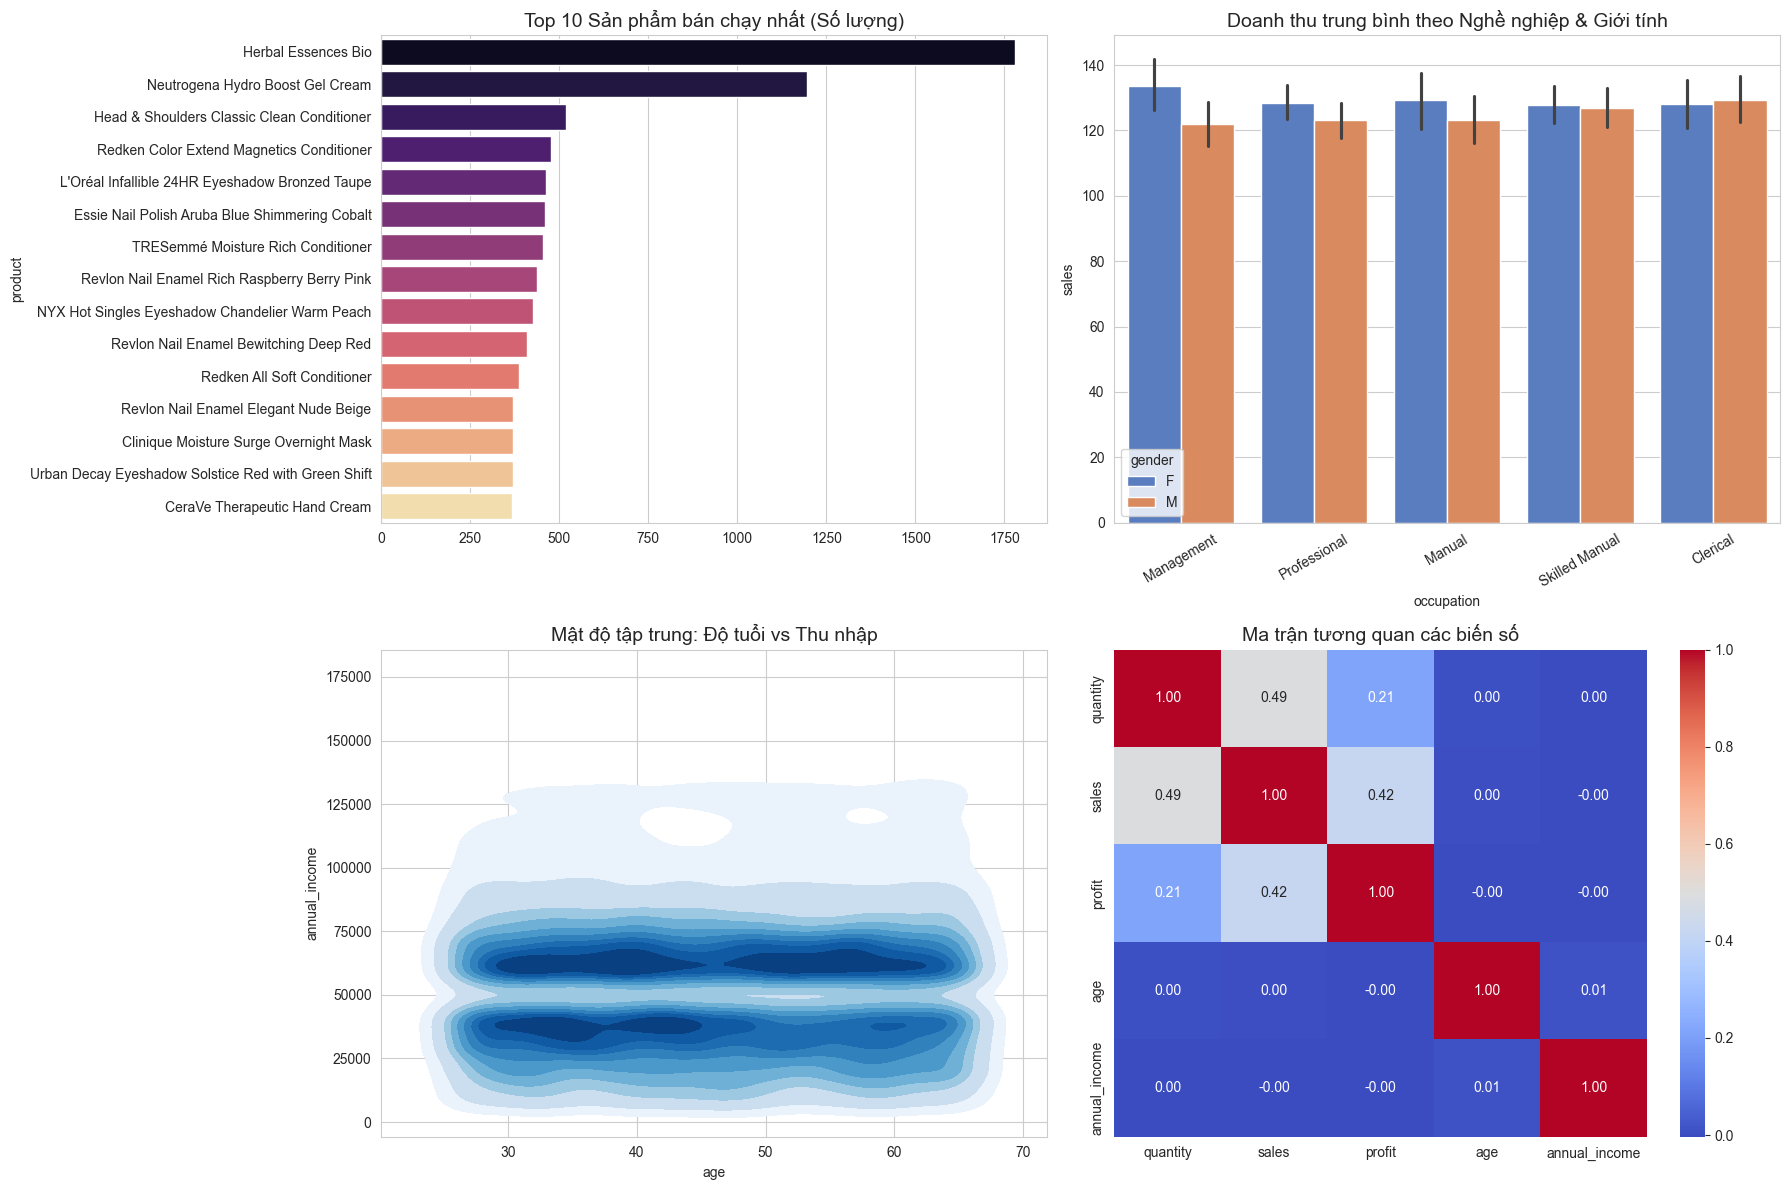

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
fig, axes = plt.subplots(2, 2, figsize=(18, 12))

# Top sp được mua nhiều nhất (Quantity)
top_products = df.groupby('product')['quantity'].sum().sort_values(ascending=False).head(15)
sns.barplot(x=top_products.values, y=top_products.index, ax=axes[0, 0], palette='magma')
axes[0, 0].set_title('Top 10 Sản phẩm bán chạy nhất (Số lượng)', fontsize=14)

# Doanh thu trung bình theo Nghề nghiệp & Giới tính
sns.barplot(data=df, x='occupation', y='sales', hue='gender', ax=axes[0, 1], palette='muted')
axes[0, 1].set_title('Doanh thu trung bình theo Nghề nghiệp & Giới tính', fontsize=14)
axes[0, 1].tick_params(axis='x', rotation=30)

# Phân bố Độ tuổi và Thu nhập hàng năm
# Giúp xác định các phân khúc khách hàng mục tiêu
sns.kdeplot(data=df, x='age', y='annual_income', fill=True, cmap='Blues', ax=axes[1, 0])
axes[1, 0].set_title('Mật độ tập trung: Độ tuổi vs Thu nhập', fontsize=14)

# Tương quan giữa các biến số (Correlation Heatmap)
numeric_df = df[['quantity', 'sales', 'profit', 'age', 'annual_income']]
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm', fmt=".2f", ax=axes[1, 1])
axes[1, 1].set_title('Ma trận tương quan các biến số', fontsize=14)

plt.tight_layout()
plt.show()

1. Phân tích từng biểu đồ
- Top 10 Sản phẩm bán chạy nhất (Số lượng)
    + Tại sao dùng: Đây là bước để xác định Popularity-based Baseline. Trong hệ thống gợi ý, nếu không biết gì về người dùng (khách mới), ta sẽ gợi ý những món này
    + Insight từ ảnh: "Herbal Essences Bio" và "Neutrogena Hydro Boost" đang áp đảo hoàn toàn.
    + Nhận định: Khoảng cách giữa sản phẩm thứ 1 và thứ 15 rất lớn. Điều này cảnh báo về hiện tượng Long Tail (Sản phẩm phổ biến thì bán cực nhiều, sản phẩm ngách thì không ai mua)
    --> Cần xử lý sao cho hệ thống không chỉ gợi ý mãi mấy món đầu bảng này

- Doanh thu trung bình theo Nghề nghiệp & Giới tính
    + Tại sao dùng: Để tìm sự khác biệt trong sức mua của các phân khúc khách hàng (Segmentation)
    + Insight từ ảnh: Sức mua khá đồng đều giữa các nhóm nghề nghiệp, nhưng giới tính Nữ (F) có xu hướng chi tiêu nhỉnh hơn Nam (M) ở hầu hết các nhóm (đặc biệt là Management)
    + Nhận định: Khi làm Hybrid Recommender, ta có thể tăng trọng số gợi ý các mặt hàng giá trị cao cho nhóm khách hàng Nữ trong bộ phận Quản lý

- Mật độ tập trung: Độ tuổi vs Thu nhập
    + Tại sao dùng: Biểu đồ KDE (Kernel Density Estimate) này giúp xác định "điểm ngọt" (Sweet spot) của thị trường
    + Insight từ ảnh: Dữ liệu tập trung cực mạnh thành 2 dải thu nhập (khoảng 35k và 60k) trải dài từ 30 đến gần 70 tuổi
    + Nhận định: Khách hàng của bạn không phải là giới trẻ (dưới 20) mà là người trưởng thành. Thu nhập có sự phân hóa rõ rệt. Hệ thống gợi ý cần phân phối sản phẩm theo hai tầng giá khác nhau để khớp với 2 dải thu nhập này

- Ma trận tương quan các biến số (Correlation Heatmap)
    + Tại sao dùng: Kiểm tra xem các biến số có "đi cùng nhau" không
    + Insight từ ảnh: 
        - Quantity và Sales có tương quan trung bình (0.49).
        - Age và Annual_Income gần như không có tương quan (0.01) --> Đây là một vấn đề quan trọng
    + Nhận định: từ data này cho thấy tuổi tác không quyết định thu nhập --> khi gợi ý theo thu nhập, không được dùng tuổi để suy diễn mà phải dựa trực tiếp vào cột annual_income

In [10]:
user_product_counts = df.groupby('customer_id')['product_code'].nunique()
print(f"Số sản phẩm trung bình mỗi khách hàng mua: {user_product_counts.mean():.2f}")
print(f"Khách hàng mua nhiều loại nhất: {user_product_counts.max()}")

Số sản phẩm trung bình mỗi khách hàng mua: 2.93
Khách hàng mua nhiều loại nhất: 25


Số lượng User: 17415
Số lượng Sản phẩm: 3576
Độ thưa của dữ liệu (Sparsity): 99.92%


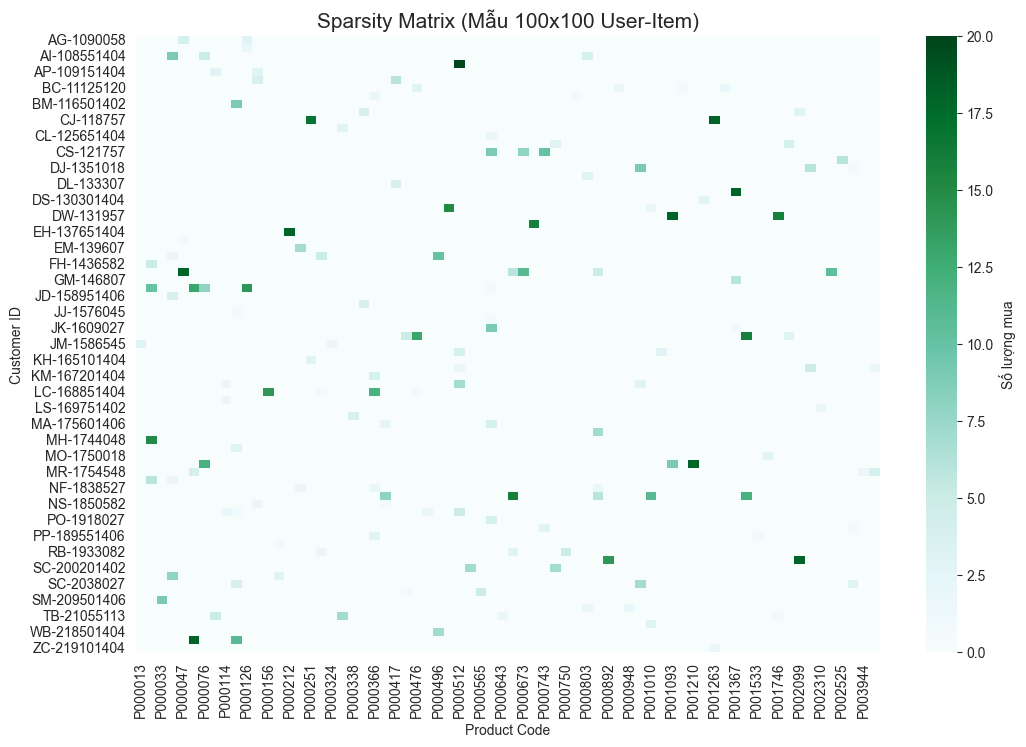

In [11]:
import numpy as np

# Tính Sparsity tổng thể
n_users = df['customer_id'].nunique()
n_items = df['product_code'].nunique()
n_interactions = len(df.groupby(['customer_id', 'product_code']))

total_possible_interactions = n_users * n_items
sparsity = (1 - n_interactions / total_possible_interactions) * 100

print(f"Số lượng User: {n_users}")
print(f"Số lượng Sản phẩm: {n_items}")
print(f"Độ thưa của dữ liệu (Sparsity): {sparsity:.2f}%")

# Trực quan hóa một phần ma trận (User-Item Matrix Heatmap)
top_users = df['customer_id'].value_counts().head(100).index
top_items = df['product_code'].value_counts().head(100).index

sample_df = df[df['customer_id'].isin(top_users) & df['product_code'].isin(top_items)]
user_item_matrix = sample_df.pivot_table(index='customer_id', columns='product_code', values='quantity').fillna(0)

plt.figure(figsize=(12, 8))
sns.heatmap(user_item_matrix, cmap='BuGn', cbar_kws={'label': 'Số lượng mua'})
plt.title('Sparsity Matrix (Mẫu 100x100 User-Item)', fontsize=15)
plt.xlabel('Product Code')
plt.ylabel('Customer ID')
plt.show()

1. Độ thưa 99.92% nghĩa là trong 10,000 ô của ma trận User-Item, chỉ có 8 ô là có dữ liệu
- Vấn đề: Các thuật toán Collaborative Filtering (như SVD) dựa vào việc tìm người dùng có hành vi tương đồng. Với độ thưa này, rất khó để tìm được hai người dùng có đủ điểm chung để so sánh.
- Hệ quả: Nếu chỉ dùng lịch sử mua hàng, hệ thống sẽ thường xuyên trả về kết quả rỗng hoặc gợi ý không chính xác (lỗi Cold Start cho Item).

    --> Dữ liệu e-commerce có Sparsity cực cao (99.92%). Nếu áp dụng ma trận phân rã truyền thống, mô hình sẽ bị nhiễu nặng. Vì vậy, nên thiết kế hệ thống Hybrid kết hợp Content-based Filtering (sử dụng đặc trưng Category/Subcategory của sản phẩm) để lấp đầy các khoảng trống thông tin, giúp hệ thống vẫn gợi ý tốt ngay cả khi User chưa có nhiều lịch sử mua hàng.
2. Giải pháp
- Ưu tiên Content-Based (Trọng số cao hơn): Trong giai đoạn đầu, để thông tin về loại sản phẩm dẫn dắt gợi ý.
- Sử dụng Dimensionality Reduction: Dùng các kỹ thuật giảm chiều dữ liệu để nén ma trận thưa này lại thành các vector đặc trưng (Embeddings) đậm đặc hơn.
- Top Popularity: Luôn có một danh sách các sản phẩm xanh đậm nhất trên Heatmap để dự phòng cho khách hàng mới hoàn toàn.

## Content-based Filtering

In [12]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.preprocessing import OneHotEncoder
import pandas as pd
import numpy as np
from scipy.sparse import hstack

# Chuẩn bị dữ liệu sp (loại bỏ trùng lặp để tạo danh mục sp duy nhất)
item_features = df[['product_code', 'product', 'category', 'subcategory']].drop_duplicates().reset_index(drop=True)

# TF-IDF cho tên sp
tfidf = TfidfVectorizer(stop_words='english')                                               # stop_words='english': loại bỏ các từ vô nghĩa: and, the,...
tfidf_matrix = tfidf.fit_transform(item_features['product'])

# One-hot cho cate & subcate
encoder = OneHotEncoder()
cat_encoded = encoder.fit_transform(item_features[['category', 'subcategory']])

# Kết hợp all thành một ma trận đặc trưng sản phẩm - Item profile
item_profiles = hstack([tfidf_matrix, cat_encoded])                                         # dùng hstack để ghép 2 ma trận tf-idf và one-hot

print(f"Ma trận đặc trưng sản phẩm sẵn sàng: {item_profiles.shape}")

# Hàm gợi ý sp tương đồng (Content-based)
def get_content_based_recommendations(product_code, top_n=10):
    idx = item_features.index[item_features['product_code'] == product_code].tolist()[0]    # Lấy index của sp trong bảng item_features
    cosine_sim = cosine_similarity(item_profiles[idx], item_profiles).flatten()             # Tính độ tương đồng giữa sp này và tất cả sp khác
    similar_indices = cosine_sim.argsort()[-(top_n+1):-1][::-1]                             # Lấy top_n sp có độ tương đồng cao nhất (loại bỏ chính nó)
    
    return item_features.iloc[similar_indices]

# --- TEST ---
test_code = 'P000001'
recommendations = get_content_based_recommendations(test_code)

print(f"\nSản phẩm đang xem: {item_features[item_features['product_code'] == test_code]['product'].values[0]}")
print("Top 10 sản phẩm tương đồng gợi ý:")
print(recommendations[['product_code', 'product', 'category']])

Ma trận đặc trưng sản phẩm sẵn sàng: (3576, 2480)

Sản phẩm đang xem: Soap & Glory Endless Glove Moisturizing Hand Cream
Top 10 sản phẩm tương đồng gợi ý:
     product_code                                          product   category
2546      P006061           La Mer The Moisturizing Cool Gel Cream  Body care
371       P000403                      Eucerin Soothing Hand Cream  Body care
683       P000801                    Palmer's Olive Oil Hand Cream  Body care
2579      P006271  Dr. Bronner's Lavender Pure-Castile Liquid Soap  Body care
674       P000787                           Bliss Minty Hand Cream  Body care
2572      P006224             L'Occitane Cherry Blossom Hand Cream  Body care
720       P000856                Aveeno Active Naturals Hand Cream  Body care
2578      P006266               Bliss Grapefruit & Aloe Hand Cream  Body care
2201      P004288          ELEMIS Jasmine & Rose Hand & Nail Cream  Body care
678       P000794           CeraVe Itch Relief Moisturizing Lotio

## Collaborative Filtering 

In [13]:
# Dùng phân rã ma trận (Matrix Factorization) vì data có độ thưa 99,92%

from scipy.sparse.linalg import svds
from scipy.sparse import csr_matrix

# Tạo ma trận user thưa (Sparse Matrix)
user_item_pivot = df.pivot_table(index='customer_id', columns='product_code', values='quantity').fillna(0)
user_item_sparse = csr_matrix(user_item_pivot.values)                                       # chuyển sang định dạng Sparse matrix để tính nhanh

# SVD (phân rã ma trận)
U, sigma, Vt = svds(user_item_sparse, k=50)                                                 # k=50: số lượng yếu tố ẩn muốn trích xuất
sigma = np.diag(sigma)                                                                      # chuyển sigma --> ma trận đường chéo

# Ma trận dự đoán (các ô trống đã đc lấp bằng điểm dự đoán)
all_user_predicted_ratings = np.dot(np.dot(U, sigma), Vt)
preds_df = pd.DataFrame(all_user_predicted_ratings, columns=user_item_pivot.columns, index=user_item_pivot.index)

print(f'Ma trận dự đoán sẵn sàng: {preds_df.shape}')

# Hàm gợi ý theo Collaborative
def get_cf_recommendations(customer_id, top_n=10):
    user_row_number = user_item_pivot.index.get_loc(customer_id)
    sorted_user_predictions = preds_df.iloc[user_row_number].sort_values(ascending=False)
    top_product_codes = sorted_user_predictions.index[:top_n].tolist()                      # lấy danh sách product_code từ index
    recommendations = item_features[item_features['product_code'].isin(top_product_codes)]
    return recommendations

# --- Test --- 
test_user = df['customer_id'].iloc[0]
cf_recs = get_cf_recommendations(test_user)

print(f"\nKhách hàng: {test_user}")
print("Top 10 sản phẩm gợi ý dựa trên hành vi (CF):")
print(cf_recs[['product_code', 'product']])

Ma trận dự đoán sẵn sàng: (17415, 3576)

Khách hàng: CC-1267082
Top 10 sản phẩm gợi ý dựa trên hành vi (CF):
     product_code                                            product
0         P000001  Soap & Glory Endless Glove Moisturizing Hand C...
75        P000076        Revlon Nail Enamel Emerald City Matte Green
317       P000338  Revlon Nail Enamel Starry Pink Soft Pink with ...
492       P000550         Revlon Nail Enamel Bewitching Black Cherry
843       P001032      Olay Cleansing & Renewing Nighttime Body Wash
882       P001093                        Redken All Soft Conditioner
952       P001210  Aveeno Absolutely Ageless Restorative Night Cream
1315      P001836       Orly Nail Lacquer Purple Crush Bright Purple
1344      P001897  L'Oréal Paris Colour Riche Nail Color Grecian ...
2340      P004935          Aveeno Calm + Restore Oat Gel Moisturizer


## Hybrid recommender

In [30]:
from sklearn.preprocessing import MinMaxScaler
def hybrid_recommender(customer_id, product_code, alpha=0.3):
    """
    alpha: trọng số cho Content-based
    Vì Sparsity cao,  nên ưu tiên CF cho khách cũ và Content-based cho khách mới
    """
    # - lấy điểm từ Content-based (sự tương đồng của sp)
    idx = item_features.index[item_features['product_code'] == product_code].tolist()[0]
    content_sim_score = cosine_similarity(item_profiles[idx], item_profiles).flatten()

    # DataFrame điểm Content
    content_score_df = pd.DataFrame({
        'product_code': item_features['product_code'],
        'content_score': content_sim_score
    })

    # - lấy điểm từ Collaborative (dự báo hành vi User)
    user_row_number = user_item_pivot.index.get_loc(customer_id)
    cf_predictions = preds_df.iloc[user_row_number]

    # Chuẩn hóa điểm CF (để cộng với Content score)
    scaler = MinMaxScaler()
    cf_predictions_scaled = scaler.fit_transform(cf_predictions.values.reshape(-1,1)).flatten()

    cf_score_df = pd.DataFrame({
        'product_code': user_item_pivot.columns,
        'cf_score': cf_predictions_scaled
    })

    # gộp 2 điểm + tính điểm hybrid
    hybrid_df = pd.merge(content_score_df, cf_score_df, on='product_code')
    hybrid_df['final_score'] = (alpha * hybrid_df['content_score']) + ((1-alpha) * hybrid_df['cf_score'])

    # lấy top sp (loại bỏ sản phẩm đang xem)
    hybrid_df = hybrid_df[hybrid_df['product_code'] != product_code]
    top_recommendations = hybrid_df.sort_values(by='final_score', ascending=False).head(20)

    # lấy thông tin chi tiết sản phẩm
    result = pd.merge(top_recommendations, item_features, on='product_code')
    return result[['product_code', 'product', 'category', 'final_score']]


user_test = df['customer_id'].iloc[0]
prod_test = 'P000001'

print(f"Sản phẩm đang xem: {prod_test}")
print(f"Gợi ý Hybrid cho User {user_test}:")
print(hybrid_recommender(user_test, prod_test, alpha=0.4))

Sản phẩm đang xem: P000001
Gợi ý Hybrid cho User JH-159857:
   product_code                                            product   category  \
0       P000126             Revlon Nail Enamel Bewitching Deep Red  Body care   
1       P000892                Head & Shoulders Ocean Lift Shampoo  Body care   
2       P002240                         L'Occitane Rose Hand Cream  Hair care   
3       P000794             CeraVe Itch Relief Moisturizing Lotion  Body care   
4       P000828         Neutrogena Ultra Sheer Body Mist Sunscreen  Body care   
5       P000807  L'Oréal Paris EverStrong Sulfate-Free Thickeni...  Body care   
6       P000910    CND Vinylux Weekly Polish Romantique Sheer Pink  Body care   
7       P006179               Eucerin Smoothing Face Cream 5% Urea  Body care   
8       P000801                      Palmer's Olive Oil Hand Cream  Body care   
9       P000894                         Beautyblender Royal Sponge  Body care   
10      P000404                                  

## Đánh giá mô hình

Dùng Precision@K
- Ý nghĩa: trong top K sản phẩm gợi ý, thì có bao nhiêu sản phẩm thực tế khách hàng đã mua trong tương lai?
- Ý tưởng: Chia dữ liệu theo order_date, dùng dữ liệu quá khứ để train và dùng dữ liệu gần nhất để test

In [ ]:
from sklearn.model_selection import train_test_split
from scipy.sparse import csr_matrix
from scipy.sparse.linalg import svds

# 1. Chia lại dữ liệu ngẫu nhiên
train_df, test_df = train_test_split(df, test_size=0.2, random_state=42)

# 2. Xây dựng lại mô hình chỉ dựa trên train_df (Để tránh rò rỉ dữ liệu)
# Re-build Item Features
item_features = train_df[['product_code', 'product', 'category', 'subcategory']].drop_duplicates().reset_index(drop=True)

# Re-build Item Profiles (TF-IDF + OneHot)
tfidf_matrix = tfidf.fit_transform(item_features['product'])
cat_encoded = encoder.fit_transform(item_features[['category', 'subcategory']])
item_profiles = hstack([tfidf_matrix, cat_encoded])

# Re-build CF components (Pivot + SVD)
user_item_pivot = train_df.pivot_table(index='customer_id', columns='product_code', values='quantity').fillna(0)
user_item_sparse = csr_matrix(user_item_pivot.values)
U, sigma, Vt = svds(user_item_sparse, k=50)
sigma = np.diag(sigma)
preds_df = pd.DataFrame(np.dot(np.dot(U, sigma), Vt), columns=user_item_pivot.columns, index=user_item_pivot.index)

# 3. Hàm đánh giá đã sửa lỗi IndexError
def evaluate_by_category_fixed(test_data):
    # Chỉ lấy những khách hàng có trong cả train và test
    train_customers = set(train_df['customer_id'])
    test_customers = set(test_data['customer_id'])
    common_customers = list(train_customers.intersection(test_customers))
    
    hits = 0
    total_valid_customers = 0
    
    for customer_id in common_customers:
        # Lấy lịch sử trong tập train
        history = train_df[train_df['customer_id'] == customer_id]
        
        # KIỂM TRA: Nếu khách hàng không có dữ liệu trong train thì bỏ qua
        if history.empty:
            continue
            
        last_product = history['product_code'].iloc[-1]
        
        # KIỂM TRA: Nếu sản phẩm này không có trong item_features của tập train thì bỏ qua
        if last_product not in item_features['product_code'].values:
            continue
            
        actual_categories = set(test_data[test_data['customer_id'] == customer_id]['category'])
        
        try:
            # Gợi ý dựa trên mô hình đã train lại
            recommendations = hybrid_recommender(customer_id, last_product, alpha=0.4)
            recommended_categories = set(recommendations['category'])
            
            # So khớp danh mục
            if len(actual_categories.intersection(recommended_categories)) > 0:
                hits += 1
            total_valid_customers += 1
        except:
            continue
            
    return (hits / total_valid_customers * 100) if total_valid_customers > 0 else 0

# Chạy đánh giá mới
final_precision = evaluate_by_category_fixed(test_df)
print(f"New Train size: {len(train_df)}")
print(f"New Test size: {len(test_df)}")
print(f"Category Precision Rate: {final_precision:.2f}%")

Tập train: 41029
Tập test: 17
--- Debugging for 0 customers ---
Category Precision Rate: 0.00%
